In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_preds_for_landmark(landmark: str, hop: int = 1, deg: int = 2,
                            model_tag: str = "sex_adaptive",
                            preds_dir: str = "./preds"):
    """
    Load the prediction CSV you saved during training.

    Expected columns:
      sid, landmark, sex, age, age_next, dt, x_pred, y_pred, x_true, y_true
    """
    fname = f"preds_{landmark.replace(' ', '_')}_hop{hop}_deg{deg}_{model_tag}.csv"
    path = os.path.join(preds_dir, fname)
    df = pd.read_csv(path)
    return df, path


def plot_sid_predictions_with_2mm(df: pd.DataFrame,
                                  sids=None,
                                  max_sids: int = 4,
                                  radius_mm: float = 2.0,
                                  title_prefix: str = ""):
    """
    For each selected sid, plot:
      - true XY points + solid low-opacity trajectory line
      - predicted XY points
      - dashed segment from each true point to its prediction
      - 2 mm circle around each true point.

    df must have:
      sid, x_true, y_true, x_pred, y_pred, age_next (or age)
    """
    # choose SIDs
    all_sids = df["sid"].astype(str).unique()
    if sids is None:
        chosen = all_sids[:min(max_sids, len(all_sids))]
    else:
        sids = [str(s) for s in sids]
        chosen = [s for s in sids if s in all_sids]
        if len(chosen) == 0:
            raise ValueError("None of the requested sids are in this prediction file.")

    n = len(chosen)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), squeeze=False)

    for ax, sid in zip(axes.ravel(), chosen):
        sub = df[df["sid"].astype(str) == sid].copy()

        # temporal order: age_next if present, else age
        if "age_next" in sub.columns:
            sub = sub.sort_values("age_next")
        elif "age" in sub.columns:
            sub = sub.sort_values("age")

        x_true = sub["x_true"].to_numpy(float)
        y_true = sub["y_true"].to_numpy(float)
        x_pred = sub["x_pred"].to_numpy(float)
        y_pred = sub["y_pred"].to_numpy(float)

        # --- markers ---
        # true trajectory (solid, low opacity)
        ax.plot(x_true, y_true, "-", linewidth=1.2, alpha=0.4, color="C0", label="_nolegend_")

        # true points
        true_sc = ax.scatter(x_true, y_true, s=40, color="C0", label="True")

        # predicted points
        pred_sc = ax.scatter(x_pred, y_pred, marker="x", s=60, color="C1", label="Pred")

        # dashed segment from true -> pred for each timepoint
        for xt, yt, xp, yp in zip(x_true, y_true, x_pred, y_pred):
            ax.plot([xt, xp], [yt, yp], "--", linewidth=0.8, alpha=0.6,
                    color="0.5", label="_nolegend_")

        # 2mm circle around each true point
        for xt, yt in zip(x_true, y_true):
            circ = plt.Circle((xt, yt), radius=radius_mm,
                              fill=False, linestyle="--", linewidth=0.8, color="C2")
            ax.add_patch(circ)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x (mm)")
        ax.set_ylabel("y (mm)")
        ax.set_title(f"sid={sid}  (n={len(sub)})")

    # global legend (True / Pred)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    if not title_prefix:
        title_prefix = df["landmark"].iloc[0] if "landmark" in df.columns else ""
    fig.suptitle(f"{title_prefix} – true vs predicted (2 mm radius, dashed error segments)",
                 y=0.98)

    fig.tight_layout(rect=[0, 0, 0.95, 0.94])
    plt.show()


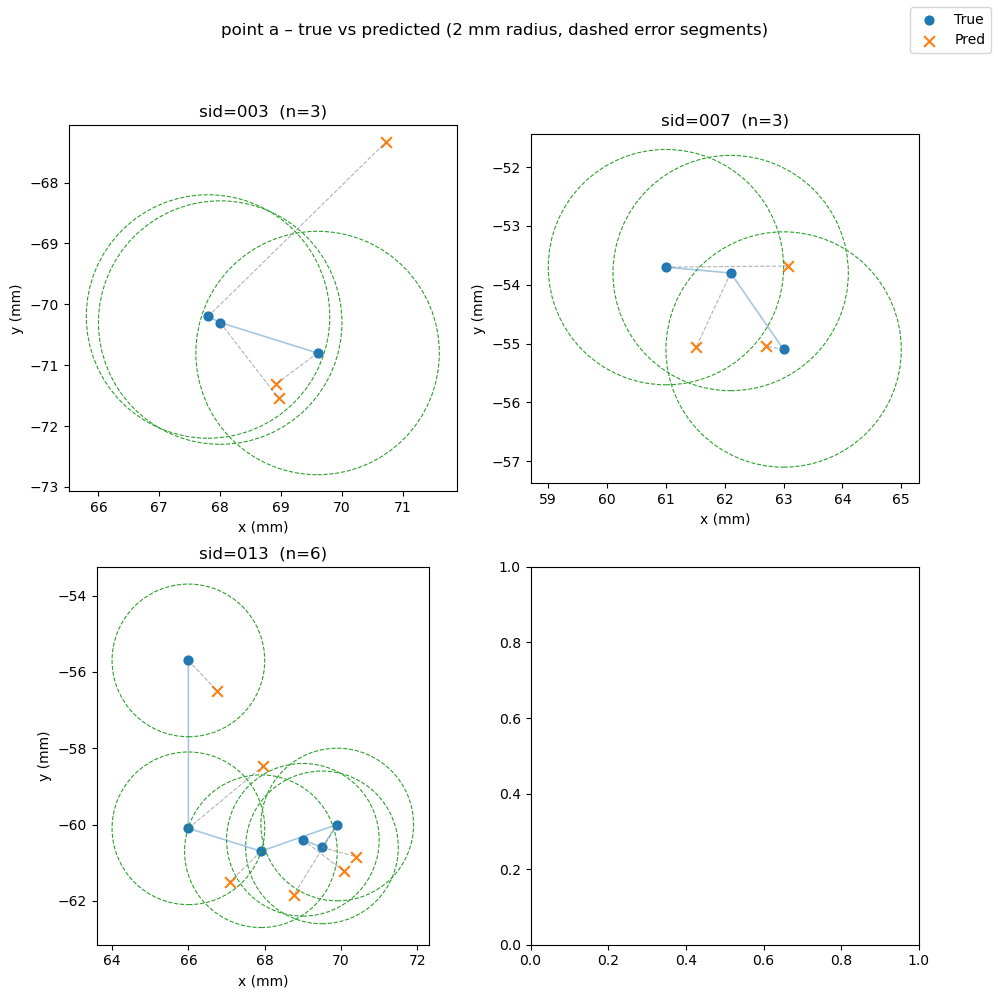

In [11]:
df_sella, _ = load_preds_for_landmark("point_a", hop=1, deg=2)
# plot_sid_predictions_with_2mm(df_sella, max_sids=4, radius_mm=2.0)

plot_sid_predictions_with_2mm(df_sella, sids=['003', '007', '013'], radius_mm=2.0)


In [ ]:
def load_preds_for_landmarks(landmarks, hop=1, deg=2,
                             model_tag="sex_adaptive",
                             preds_dir="./preds"):
    """Return dict: landmark -> df."""
    out = {}
    for lm in landmarks:
        fname = f"preds_{lm.replace(' ', '_')}_hop{hop}_deg{deg}_{model_tag}.csv"
        path = os.path.join(preds_dir, fname)
        out[lm] = pd.read_csv(path)
    return out


def plot_sid_multi_landmarks(pred_dict, sid, radius_mm=2.0, connect_error=True,xmin=None, xmax=None, ymin=None, ymax=None):
    """
    pred_dict: {landmark_name: df}
    For a single sid, overlay multiple landmarks on one plot.
    """
    sid = str(sid)
    fig, ax = plt.subplots(figsize=(6, 6))

    for i, (lm, df) in enumerate(pred_dict.items()):
        sub = df[df["sid"].astype(str) == sid].copy()
        if sub.empty:
            continue

        # temporal sort
        if "age_next" in sub.columns:
            sub = sub.sort_values("age_next")
        elif "age" in sub.columns:
            sub = sub.sort_values("age")

        x_true = sub["x_true"].to_numpy(float)
        y_true = sub["y_true"].to_numpy(float)
        x_pred = sub["x_pred"].to_numpy(float)
        y_pred = sub["y_pred"].to_numpy(float)

        color = f"C{i % 10}"

        # actual trajectory per landmark
        ax.plot(x_true, y_true, "-", linewidth=1.0, alpha=0.4,
                color=color, label=f"{lm} true" if i == 0 else "_nolegend_")

        # true and pred markers
        ax.scatter(x_true, y_true, s=35, color=color,
                   label=f"{lm} true" if i == 0 else "_nolegend_")
        ax.scatter(x_pred, y_pred, marker="x", s=55, color=color,
                   alpha=0.9, label=f"{lm} pred" if i == 0 else "_nolegend_")

        if connect_error:
            for xt, yt, xp, yp in zip(x_true, y_true, x_pred, y_pred):
                ax.plot([xt, xp], [yt, yp], "--", linewidth=0.7, alpha=0.6,
                        color=color, label="_nolegend_")

        # optional: 2mm circles (might get busy with many landmarks)
        for xt, yt in zip(x_true, y_true):
            circ = plt.Circle((xt, yt), radius=radius_mm,
                              fill=False, linestyle="--", linewidth=0.6, color=color, alpha=0.5)
            ax.add_patch(circ)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"sid={sid} – multiple landmarks")

        # --- manual limits to avoid a narrow plot ---
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin, xmax)

    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin, ymax)

    


    # one legend, just show one pair of entries
    handles, labels = ax.get_legend_handles_labels()
    # remove duplicates
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc="upper right")

    fig.tight_layout()
    plt.show()


In [ ]:
landmarks = ["point_a", "point_b"]  # whatever small subset you want
pred_dict = load_preds_for_landmarks(landmarks, hop=1, deg=2)

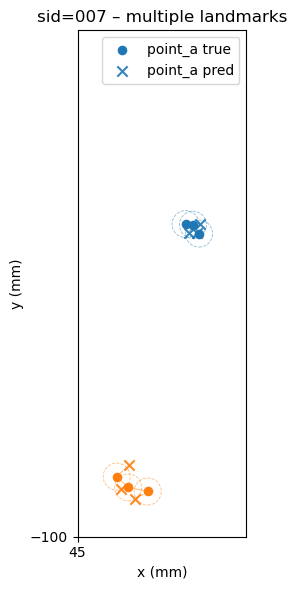

In [39]:

plot_sid_multi_landmarks(pred_dict, sid='007', radius_mm=2.0,xmin=45, xmax=70, ymin=-100, ymax=-25)


In [2]:
import plotly.graph_objects as go

def plot_sid_multi_landmarks_plotly(pred_dict, sid, radius_mm=2.0,
                                    x_range=None, y_range=None):
    sid = str(sid)
    fig = go.Figure()

    for i, (lm, df) in enumerate(pred_dict.items()):
        sub = df[df["sid"].astype(str) == sid].copy()
        if sub.empty:
            continue

        if "age_next" in sub.columns:
            sub = sub.sort_values("age_next")
        elif "age" in sub.columns:
            sub = sub.sort_values("age")

        x_true = sub["x_true"].to_numpy(float)
        y_true = sub["y_true"].to_numpy(float)
        x_pred = sub["x_pred"].to_numpy(float)
        y_pred = sub["y_pred"].to_numpy(float)

        color = f"hsl({(i*60) % 360},70%,50%)"

        # true trajectory
        fig.add_trace(go.Scatter(
            x=x_true, y=y_true, mode="lines+markers",
            name=f"{lm} true",
            line=dict(width=1),
            marker=dict(size=8)
        ))

        # predicted points
        fig.add_trace(go.Scatter(
            x=x_pred, y=y_pred, mode="markers",
            name=f"{lm} pred",
            marker=dict(symbol="x", size=10)
        ))

        # dashed lines true -> pred
        for xt, yt, xp, yp in zip(x_true, y_true, x_pred, y_pred):
            fig.add_shape(
                type="line", x0=xt, y0=yt, x1=xp, y1=yp,
                line=dict(color="gray", width=1, dash="dot")
            )
            # 2mm circle around true
            fig.add_shape(
                type="circle",
                x0=xt - radius_mm, x1=xt + radius_mm,
                y0=yt - radius_mm, y1=yt + radius_mm,
                line=dict(color='green', width=1, dash="dot"),
                fillcolor="rgba(0,0,0,0)"
            )

    fig.update_layout(
        title=f"sid={sid} – multiple landmarks",
        xaxis_title="x (mm)",
        yaxis_title="y (mm)",
        width=700,
        height=700,
        yaxis=dict(scaleanchor="x", scaleratio=1)  # keep mm aspect
    )

    # manual zoom if you want:
    if x_range is not None:
        fig.update_xaxes(range=list(x_range))
    if y_range is not None:
        fig.update_yaxes(range=list(y_range))

    fig.show()


In [50]:
plot_sid_multi_landmarks_plotly(
    pred_dict, sid="007",
    radius_mm=2.0,
)


In [15]:
import os
import pandas as pd
import plotly.graph_objects as go

def load_preds_for_landmarks(landmarks, hop=1, deg=2,
                             model_tag="sex_adaptive",
                             preds_dir="./preds"):
    """Return dict: landmark -> df."""
    out = {}
    for lm in landmarks:
        fname = f"preds_{lm.replace(' ', '_')}_hop{hop}_deg{deg}_{model_tag}.csv"
        path = os.path.join(preds_dir, fname)
        if not os.path.exists(path):
            print(f"[WARN] File not found for landmark '{lm}': {path}")
            continue
        out[lm] = pd.read_csv(path)
    return out


def plot_sid_multi_landmarks_plotly(
    landmarks,
    sid,
    hop: int = 1,
    deg: int = 2,
    model_tag: str = "sex_adaptive",
    preds_dir: str = "./preds",
    radius_mm: float = 2.0,
    x_range=None,
    y_range=None,
    exclude_landmarks=None,   # list of landmarks to skip
    n_ages: int = None        # how many ages (rows) per landmark to draw
):
    """
    landmarks: list of landmark names (as used in filenames).
    sid: subject id to plot (str or int).
    hop, deg, model_tag, preds_dir: control which prediction CSVs to load.
    radius_mm: radius of circle around each true point.
    x_range, y_range: optional (min, max) tuples for manual zoom.
    exclude_landmarks: list of landmark names to exclude.
    n_ages: if not None, use only the first n timepoints for that sid
            (after sorting by age_next / age) for each landmark.
    """
    sid = str(sid)

    # filter landmarks by exclude list
    exclude_set = set(exclude_landmarks) if exclude_landmarks is not None else set()
    lm_to_use = [lm for lm in landmarks if lm not in exclude_set]

    # load CSVs into dict {landmark -> df}
    pred_dict = load_preds_for_landmarks(
        lm_to_use, hop=hop, deg=deg,
        model_tag=model_tag, preds_dir=preds_dir
    )

    fig = go.Figure()

    for i, (lm, df) in enumerate(pred_dict.items()):
        # subset this landmark to the sid
        sub = df[df["sid"].astype(str) == sid].copy()
        if sub.empty:
            continue

        # sort by time
        if "age_next" in sub.columns:
            sub = sub.sort_values("age_next")
        elif "age" in sub.columns:
            sub = sub.sort_values("age")

        # keep only first n_ages rows if requested
        if n_ages is not None and n_ages > 0:
            sub = sub.head(n_ages)
        if sub.empty:
            continue

        x_true = sub["x_true"].to_numpy(float)
        y_true = sub["y_true"].to_numpy(float)
        x_pred = sub["x_pred"].to_numpy(float)
        y_pred = sub["y_pred"].to_numpy(float)

        color = f"hsl({(i*60) % 360},70%,50%)"

        # true trajectory
        fig.add_trace(go.Scatter(
            x=x_true,
            y=y_true,
            mode="lines+markers",
            name=f"{lm} true",
            line=dict(width=1, color=color),
            marker=dict(size=8, color=color)
        ))

        # predicted points
        fig.add_trace(go.Scatter(
            x=x_pred,
            y=y_pred,
            mode="markers",
            name=f"{lm} pred",
            marker=dict(symbol="x", size=10, color=color)
        ))

        # dashed lines true -> pred + 2mm circles
        for xt, yt, xp, yp in zip(x_true, y_true, x_pred, y_pred):
            # error segment
            fig.add_shape(
                type="line",
                x0=xt, y0=yt, x1=xp, y1=yp,
                line=dict(color="gray", width=1, dash="dot")
            )
            # 2mm circle around true
            fig.add_shape(
                type="circle",
                x0=xt - radius_mm, x1=xt + radius_mm,
                y0=yt - radius_mm, y1=yt + radius_mm,
                line=dict(color="green", width=1, dash="dot"),
                fillcolor="rgba(0,0,0,0)"
            )

    fig.update_layout(
        title=f"sid={sid} – multiple landmarks",
        xaxis_title="x (mm)",
        yaxis_title="y (mm)",
        width=800,
        height=700,
        yaxis=dict(scaleanchor="x", scaleratio=1)  # keep mm aspect
    )

    # manual zoom if you want:
    if x_range is not None:
        fig.update_xaxes(range=list(x_range), autorange=False)
    if y_range is not None:
        fig.update_yaxes(range=list(y_range), autorange=False)

    fig.show()


In [16]:
landmarks = ['sella','nasion','porion','orbitale','u i apex','point a','u i edge','l i edge','point b','l i apex','pogonion','menton','u 6 apex','u 6 cusp','l 6 cusp','l 6 apex','gonion l','gonion u','condyle','pns','basion','u_6_mcp','l_6_mcp','ans','articular','mid gonion']

In [ ]:
landmarks = ['nasion',
             'point a','point b',
             'pogonion','menton',
            'condyle','pns','basion',
             'ans','mid gonion']

landmarks, t0(x,y), t1(x,y),mae t0-t1, t2(x,y), mae t1-t2, t3(x,y), mae t2-t3
10-15

In [20]:
exclude =  ['sella','nasion','u i apex','u i edge','l i edge','pns','l i apex','u 6 apex','u 6 cusp','l 6 cusp','l 6 apex','gonion l','gonion u','u_6_mcp','l_6_mcp','mid gonion']

In [21]:
plot_sid_multi_landmarks_plotly(
    landmarks=landmarks,
    sid='007',
    hop=1,
    deg=2,
    model_tag="sex_adaptive",
    preds_dir="./preds",
    radius_mm=2.0,
    exclude_landmarks=exclude,
    n_ages=1,
    x_range=(-50, 100),
    y_range=(-110, -10)
)


In [17]:
data = pd.read_csv("./preds/preds_ans_hop2_deg2_sex_adaptive.csv")
sid = data['sid'].unique()

In [ ]:
for s in sid:
    plot_sid_multi_landmarks_plotly(
    landmarks=['menton', 'pgonion', 'point b'],
    sid=s,
    hop=1,
    deg=2,
    model_tag="sex_adaptive",
    preds_dir="./preds",
    radius_mm=2.0,
    n_ages=5,
)


In [56]:
# import os
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.patches import Circle


# def plot_sid_multi_landmarks_matplotlib(
#     landmarks,
#     sid,
#     hop: int = 1,
#     deg: int = 2,
#     model_tag: str = "sex_adaptive",
#     preds_dir: str = "./preds",
#     radius_mm: float = 2.0,
#     x_min=None,
#     x_max=None,
#     y_min=None,
#     y_max=None,
#     exclude_landmarks=None,   # list of landmarks to skip
#     n_age: int = None         # which age index to show (1-based)
# ):
#     """
#     Matplotlib version.

#     - White background, no grid
#     - Strong contrasting colors (tab10)
#     - Bigger markers and text
#     - No legend (colors differ by landmark)
#     - Tight cropping, or manual with x_min/x_max/y_min/y_max

#     n_age:
#       * If None -> plot full trajectories (all ages) per landmark.
#       * If k (1-based) -> sort rows by age/age_next and
#         use only the k-th row for that sid & landmark.
#         If that landmark has < k rows, it is skipped.
#     """
#     sid = str(sid)

#     # filter landmarks by exclude list
#     exclude_set = set(exclude_landmarks) if exclude_landmarks is not None else set()
#     lm_to_use = [lm for lm in landmarks if lm not in exclude_set]

#     # load CSVs into dict {landmark -> df}
#     pred_dict = load_preds_for_landmarks(
#         lm_to_use, hop=hop, deg=deg,
#         model_tag=model_tag, preds_dir=preds_dir
#     )

#     # ---- Matplotlib figure / axes ----
#     fig, ax = plt.subplots(figsize=(8, 7))  # similar to 800x700
#     fig.patch.set_facecolor("white")
#     ax.set_facecolor("white")
#     ax.grid(False)

#     # contrasting colors: use tab10 cycle
#     color_cycle = plt.get_cmap("tab10").colors

#     # track global bounds for tight cropping
#     global_min_x, global_max_x = None, None
#     global_min_y, global_max_y = None, None

#     for i, (lm, df) in enumerate(pred_dict.items()):
#         # subset this landmark to the sid
#         sub = df[df["sid"].astype(str) == sid].copy()
#         if sub.empty:
#             continue

#         # sort by time
#         if "age_next" in sub.columns:
#             sub = sub.sort_values("age_next")
#         elif "age" in sub.columns:
#             sub = sub.sort_values("age")

#         # --- USE n_age-th row if specified ---
#         if n_age is not None:
#             # 1-based index: n_age=1 -> first row
#             if len(sub) < n_age:
#                 # not enough timepoints for this landmark -> skip it
#                 continue
#             sub = sub.iloc[[n_age - 1]]  # keep as DataFrame of length 1

#         if sub.empty:
#             continue

#         x_true = sub["x_true"].to_numpy(float)
#         y_true = sub["y_true"].to_numpy(float)
#         x_pred = sub["x_pred"].to_numpy(float)
#         y_pred = sub["y_pred"].to_numpy(float)

#         # update global bounds (for auto-zoom)
#         local_min_x = min(x_true.min(), x_pred.min()) - radius_mm
#         local_max_x = max(x_true.max(), x_pred.max()) + radius_mm
#         local_min_y = min(y_true.min(), y_pred.min()) - radius_mm
#         local_max_y = max(y_true.max(), y_pred.max()) + radius_mm

#         if global_min_x is None:
#             global_min_x, global_max_x = local_min_x, local_max_x
#             global_min_y, global_max_y = local_min_y, local_max_y
#         else:
#             global_min_x = min(global_min_x, local_min_x)
#             global_max_x = max(global_max_x, local_max_x)
#             global_min_y = min(global_min_y, local_min_y)
#             global_max_y = max(global_max_y, local_max_y)

#         color = color_cycle[i % len(color_cycle)]

#         # true trajectory / point
#         ax.plot(
#             x_true,
#             y_true,
#             linestyle="-",
#             linewidth=2.0,
#             marker="o",
#             markersize=9,   # bigger marker
#             color=color
#         )

#         # predicted points
#         ax.scatter(
#             x_pred,
#             y_pred,
#             marker="x",
#             s=100,          # bigger crosses
#             linewidths=2.0,
#             color=color
#         )

#         # dashed lines true -> pred + 2mm circles
#         for xt, yt, xp, yp in zip(x_true, y_true, x_pred, y_pred):
#             # error segment
#             ax.plot(
#                 [xt, xp],
#                 [yt, yp],
#                 color="gray",
#                 linewidth=1.0,
#                 linestyle="dotted"
#             )
#             # 2mm circle around true
#             circ = Circle(
#                 (xt, yt),
#                 radius_mm,
#                 edgecolor="green",
#                 facecolor="none",
#                 linewidth=1.0,
#                 linestyle="dotted"
#             )
#             ax.add_patch(circ)

#     # axis labels and title: larger font
#     ax.set_title(f"sid={sid} – multiple landmarks", fontsize=18)
#     ax.set_xlabel("x (mm)", fontsize=16)
#     ax.set_ylabel("y (mm)", fontsize=16)

#     # ticks slightly larger too
#     ax.tick_params(labelsize=14)

#     # keep mm aspect
#     ax.set_aspect("equal", adjustable="box")

#     # ---- manual crop if provided, else auto with tiny padding ----
#     if x_min is not None and x_max is not None:
#         ax.set_xlim(x_min, x_max)
#     elif global_min_x is not None:
#         pad_x = 0.03 * (global_max_x - global_min_x if global_max_x > global_min_x else 1.0)
#         ax.set_xlim(global_min_x - pad_x, global_max_x + pad_x)

#     if y_min is not None and y_max is not None:
#         ax.set_ylim(y_min, y_max)
#     elif global_min_y is not None:
#         pad_y = 0.03 * (global_max_y - global_min_y if global_max_y > global_min_y else 1.0)
#         ax.set_ylim(global_min_y - pad_y, global_max_y + pad_y)

#     # no legend (you’ll add it manually)
#     # ax.legend()

#     # remove extra whitespace around plot area
#     fig.tight_layout()
#     fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.08)

#     plt.show()


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def load_preds_for_landmarks(landmarks, hop=1, deg=2,
                             model_tag="sex_adaptive",
                             preds_dir="./preds"):
    """Return dict: landmark -> df."""
    out = {}
    for lm in landmarks:
        fname = f"preds_{lm.replace(' ', '_')}_hop{hop}_deg{deg}_{model_tag}.csv"
        path = os.path.join(preds_dir, fname)
        if not os.path.exists(path):
            print(f"[WARN] File not found for landmark '{lm}': {path}")
            continue
        out[lm] = pd.read_csv(path)
    return out


def plot_sid_multi_landmarks_matplotlib(
    landmarks,
    sid,
    hop: int = 1,
    deg: int = 2,
    model_tag: str = "sex_adaptive",
    preds_dir: str = "./preds",
    radius_mm: float = 2.0,
    x_min=None,
    x_max=None,
    y_min=None,
    y_max=None,
    exclude_landmarks=None,   # list of landmarks to skip
    n_age: int = None,        # which age index to show (1-based); None = all
    lm_colors=None,           # dict lm->color or list aligned with landmarks
    min_span_mm: float = 20.0 # minimum visible span per axis in mm
):
    """
    Matplotlib version of the multi-landmark plot.

    - White background, no grid
    - Strong contrasting colors (tab10 by default)
    - Bigger markers and text
    - No legend (you can add manually outside)
    - Auto bounds include 2mm circles and enforce a minimum span
    - Optional manual crop via x_min/x_max/y_min/y_max

    n_age:
      * If None -> plot full trajectories (all ages) per landmark.
      * If k (1-based) -> sort rows by age/age_next and
        use only the k-th row for that sid & landmark.
        If that landmark has < k rows, it is skipped.

    lm_colors:
      * None -> use tab10 color cycle.
      * dict -> {landmark_name: color_string}
      * list/tuple -> colors aligned with `landmarks` order.
    """
    sid = str(sid)

    # filter landmarks by exclude list
    exclude_set = set(exclude_landmarks) if exclude_landmarks is not None else set()
    lm_to_use = [lm for lm in landmarks if lm not in exclude_set]

    # load CSVs into dict {landmark -> df}
    pred_dict = load_preds_for_landmarks(
        lm_to_use, hop=hop, deg=deg,
        model_tag=model_tag, preds_dir=preds_dir
    )

    # ---- Matplotlib figure / axes ----
    fig, ax = plt.subplots(figsize=(8, 7))  # similar to 800x700
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.grid(False)

    # contrasting colors: use tab10 cycle by default
    color_cycle = plt.get_cmap("tab10").colors

    # track global bounds for auto-zoom (including circles)
    global_min_x, global_max_x = None, None
    global_min_y, global_max_y = None, None

    def pick_color(lm_name, idx):
        """Choose color based on lm_colors or fall back to tab10."""
        if lm_colors is None:
            return color_cycle[idx % len(color_cycle)]

        # dict mapping
        if isinstance(lm_colors, dict):
            if lm_name in lm_colors:
                return lm_colors[lm_name]
            return color_cycle[idx % len(color_cycle)]

        # list/tuple aligned with landmarks order
        if isinstance(lm_colors, (list, tuple)):
            if len(lm_colors) > 0:
                return lm_colors[idx % len(lm_colors)]
            return color_cycle[idx % len(color_cycle)]

        # fallback
        return color_cycle[idx % len(color_cycle)]

    for i, (lm, df) in enumerate(pred_dict.items()):
        # subset this landmark to the sid
        sub = df[df["sid"].astype(str) == sid].copy()
        if sub.empty:
            continue

        # sort by time
        if "age_next" in sub.columns:
            sub = sub.sort_values("age_next")
        elif "age" in sub.columns:
            sub = sub.sort_values("age")

        # --- USE n_age-th row if specified (1-based) ---
        if n_age is not None:
            if len(sub) < n_age:
                # not enough timepoints for this landmark -> skip it
                continue
            sub = sub.iloc[[n_age - 1]]  # keep as DataFrame of length 1

        if sub.empty:
            continue

        x_true = sub["x_true"].to_numpy(float)
        y_true = sub["y_true"].to_numpy(float)
        x_pred = sub["x_pred"].to_numpy(float)
        y_pred = sub["y_pred"].to_numpy(float)

        # update global bounds including circle radius
        min_x_pts = min(x_true.min(), x_pred.min())
        max_x_pts = max(x_true.max(), x_pred.max())
        min_y_pts = min(y_true.min(), y_pred.min())
        max_y_pts = max(y_true.max(), y_pred.max())

        local_min_x = min_x_pts - radius_mm
        local_max_x = max_x_pts + radius_mm
        local_min_y = min_y_pts - radius_mm
        local_max_y = max_y_pts + radius_mm

        if global_min_x is None:
            global_min_x, global_max_x = local_min_x, local_max_x
            global_min_y, global_max_y = local_min_y, local_max_y
        else:
            global_min_x = min(global_min_x, local_min_x)
            global_max_x = max(global_max_x, local_max_x)
            global_min_y = min(global_min_y, local_min_y)
            global_max_y = max(global_max_y, local_max_y)

        color = pick_color(lm, i)

        # true trajectory / point
        ax.plot(
            x_true,
            y_true,
            linestyle="-",
            linewidth=2.0,
            marker="o",
            markersize=9,   # bigger markers
            color=color
        )

        # predicted points
        ax.scatter(
            x_pred,
            y_pred,
            marker="x",
            s=100,          # bigger crosses
            linewidths=2.0,
            color=color
        )

        # dashed lines true -> pred + 2mm circles
        for xt, yt, xp, yp in zip(x_true, y_true, x_pred, y_pred):
            # error segment
            ax.plot(
                [xt, xp],
                [yt, yp],
                color="gray",
                linewidth=1.0,
                linestyle="dotted"
            )
            # 2mm circle around true
            circ = Circle(
                (xt, yt),
                radius_mm,
                edgecolor="green",
                facecolor="none",
                linewidth=1.0,
                linestyle="dotted"
            )
            ax.add_patch(circ)

    # If no data, bail out nicely
    if global_min_x is None:
        print(f"[WARN] No data to plot for sid={sid}")
        return

    # ---- enforce minimum span per axis (before padding) ----
    # also make sure min_span_mm is at least circle diameter + tiny margin
    eff_min_span = max(min_span_mm, 2 * radius_mm + 1.0)

    span_x = global_max_x - global_min_x
    if span_x < eff_min_span:
        cx = 0.5 * (global_min_x + global_max_x)
        global_min_x = cx - eff_min_span / 2.0
        global_max_x = cx + eff_min_span / 2.0

    span_y = global_max_y - global_min_y
    if span_y < eff_min_span:
        cy = 0.5 * (global_min_y + global_max_y)
        global_min_y = cy - eff_min_span / 2.0
        global_max_y = cy + eff_min_span / 2.0

    # axis labels and title: larger font
    ax.set_title(f"sid={sid}", fontsize=18)
    ax.set_xlabel("x (mm)", fontsize=16)
    ax.set_ylabel("y (mm)", fontsize=16)

    # ticks slightly larger too
    ax.tick_params(labelsize=14)

    # keep mm aspect
    ax.set_aspect("equal", adjustable="box")

    # ---- apply manual crop if provided, else auto with small padding ----
    # x-limits
    if x_min is not None and x_max is not None:
        ax.set_xlim(x_min, x_max)
    else:
        span_x = global_max_x - global_min_x
        pad_x = 0.03 * span_x  # small relative padding
        ax.set_xlim(global_min_x - pad_x, global_max_x + pad_x)

    # y-limits
    if y_min is not None and y_max is not None:
        ax.set_ylim(y_min, y_max)
    else:
        span_y = global_max_y - global_min_y
        pad_y = 0.03 * span_y
        ax.set_ylim(global_min_y - pad_y, global_max_y + pad_y)

    # no legend (you’ll add it manually if needed)
    # ax.legend()

    # remove extra whitespace around plot area
    fig.tight_layout()
    fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.08)

    name = "_".join([lm.replace(" ", "_") for lm in landmarks if lm not in exclude_set])

    plt.savefig(f"Plot_pred/sid_{sid}_landmarks_{name}.png", dpi=300)
    plt.show()


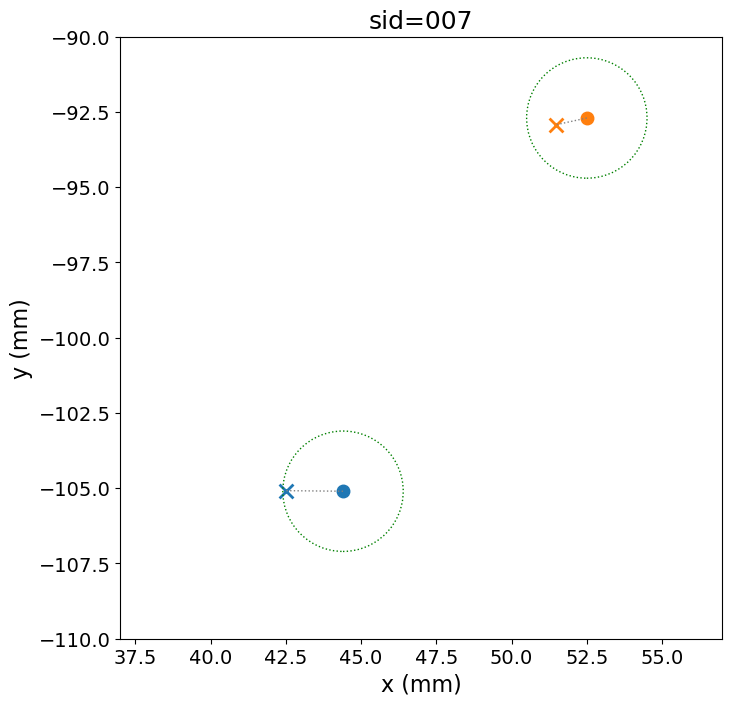

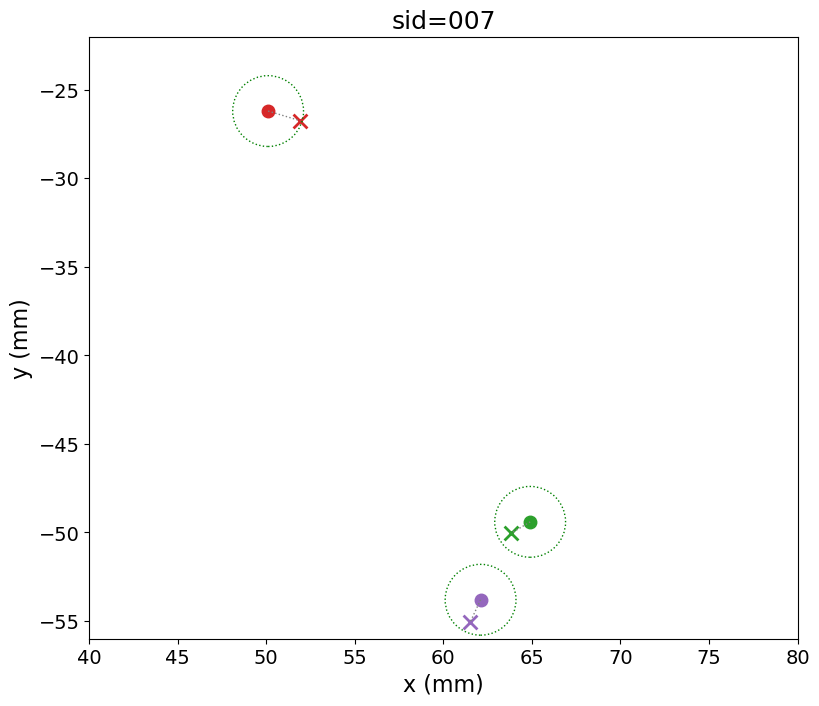

In [13]:
sid = "007"
n_age = 2

landmarks=['menton', 'point b']

lm_colors = {
    "menton": "tab:blue",
    "point b": "tab:orange",
}

plot_sid_multi_landmarks_matplotlib(
    landmarks=landmarks,
    sid=sid,
    n_age=n_age,
    lm_colors=lm_colors,
    x_min=37, x_max=57, y_min=-110, y_max=-90
)

landmarks=['ans', 'point a', 'orbitale']

lm_colors = {
    "ans" : "tab:green",
    "point a": "tab:purple",
    "orbitale": "tab:red",
}

plot_sid_multi_landmarks_matplotlib(
    landmarks=['ans', 'point a', 'orbitale'], 
    sid=sid,
    n_age=n_age,
    lm_colors=lm_colors,
    x_min=40, x_max=80, y_min=-56, y_max=-22
    )



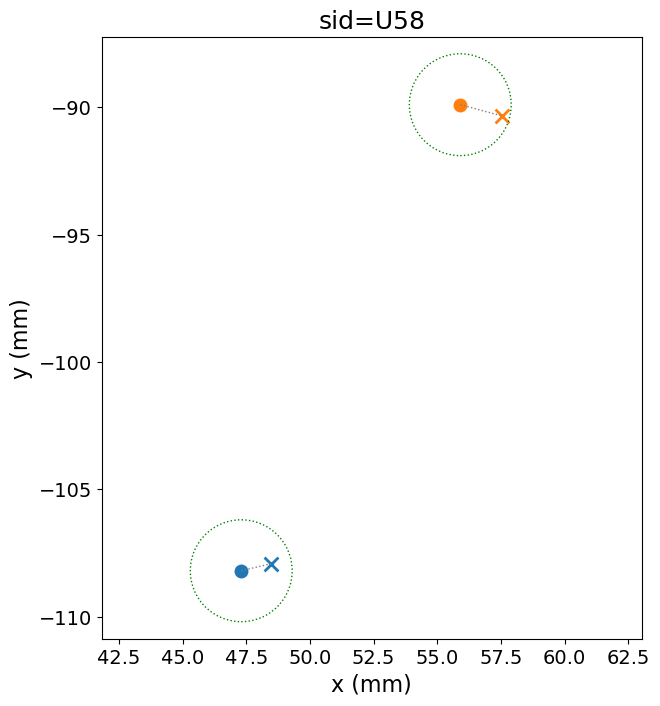

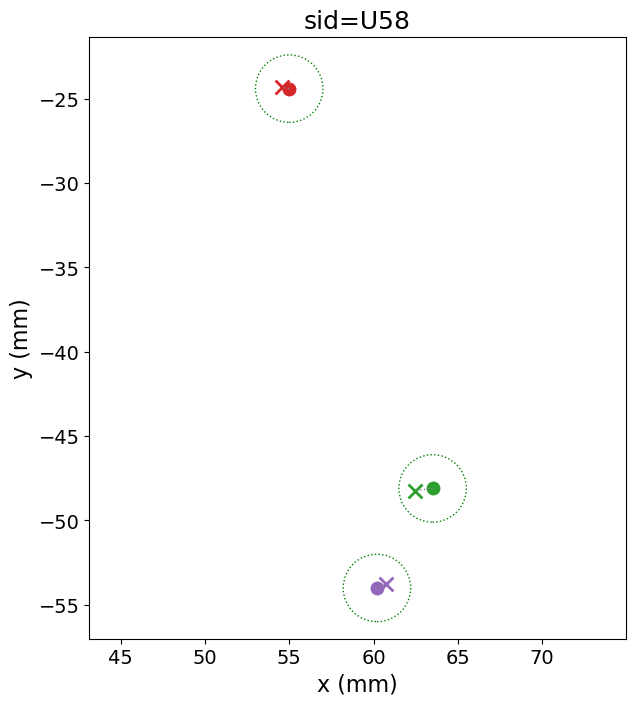

In [68]:
sid = "U58"
n_age = 3

landmarks=['menton', 'point b']

lm_colors = {
    "menton": "tab:blue",
    "point b": "tab:orange",
}

plot_sid_multi_landmarks_matplotlib(
    landmarks=landmarks,
    sid=sid,
    n_age=n_age,
    lm_colors=lm_colors,
    min_span_mm=20.0,  # make the window at least 30 mm per axis
)

landmarks=['ans', 'point a', 'orbitale']

lm_colors = {
    "ans" : "tab:green",
    "point a": "tab:purple",
    "orbitale": "tab:red",
}

plot_sid_multi_landmarks_matplotlib(
    landmarks=['ans', 'point a', 'orbitale'], 
    sid=sid,
    n_age=n_age,
    lm_colors=lm_colors,
    min_span_mm=30.0,  
    )



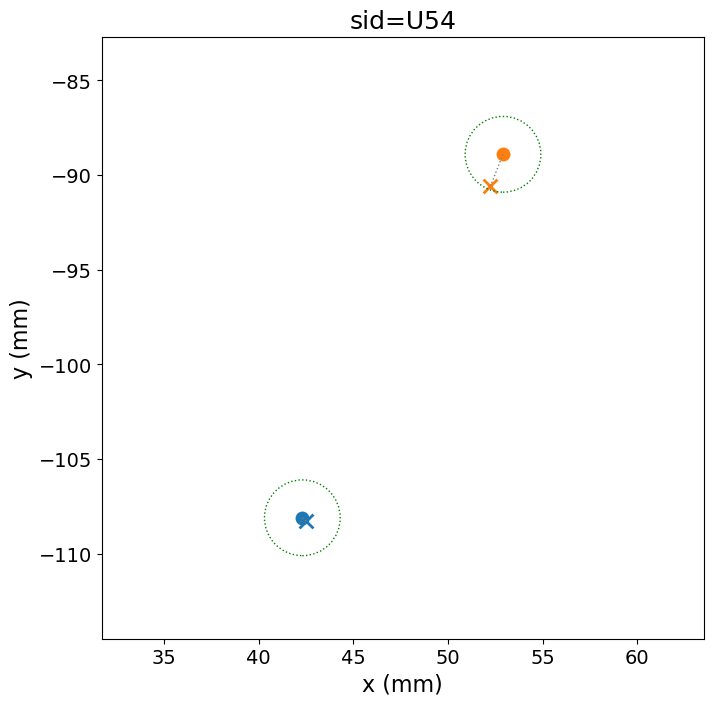

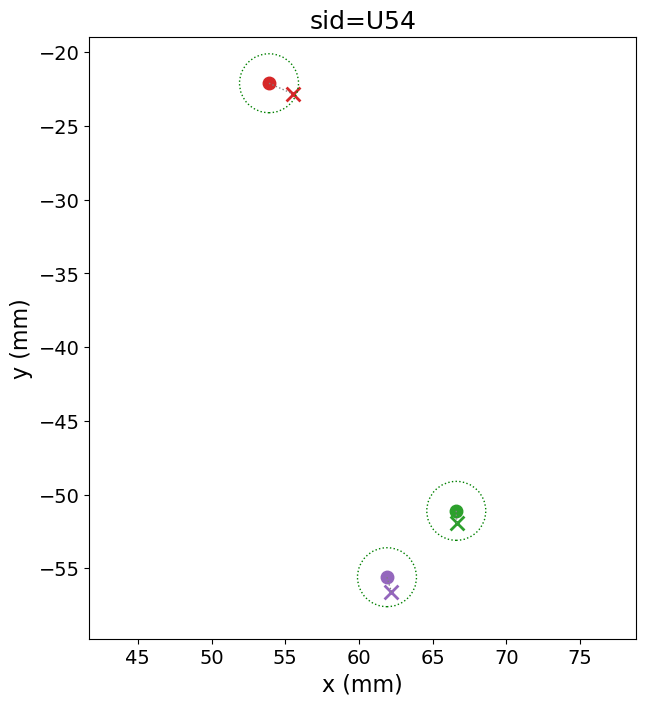

In [75]:
sid = "U54"
n_age = 3

landmarks=['menton', 'point b']

lm_colors = {
    "menton": "tab:blue",
    "point b": "tab:orange",
}

plot_sid_multi_landmarks_matplotlib(
    landmarks=landmarks,
    sid=sid,
    n_age=n_age,
    lm_colors=lm_colors,
    min_span_mm=30.0,  # make the window at least 30 mm per axis
)

landmarks=['ans', 'point a', 'orbitale']

lm_colors = {
    "ans" : "tab:green",
    "point a": "tab:purple",
    "orbitale": "tab:red",
}

plot_sid_multi_landmarks_matplotlib(
    landmarks=['ans', 'point a', 'orbitale'], 
    sid=sid,
    n_age=n_age,
    lm_colors=lm_colors,
    min_span_mm=35.0,  
    )



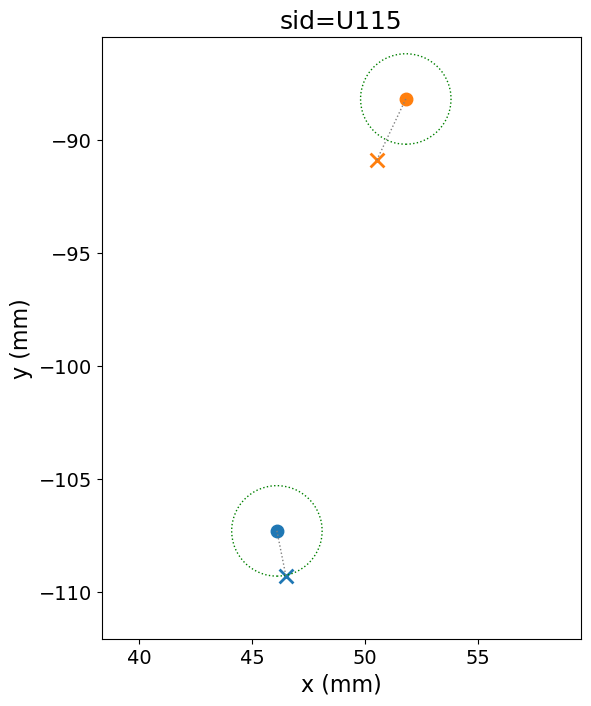

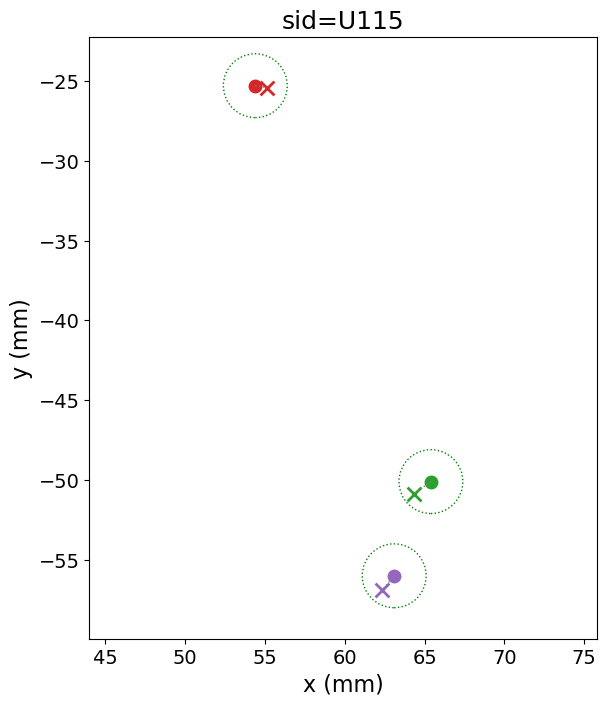

In [70]:
sid = "U115"
n_age = 3

landmarks=['menton', 'point b']

lm_colors = {
    "menton": "tab:blue",
    "point b": "tab:orange",
}

plot_sid_multi_landmarks_matplotlib(
    landmarks=landmarks,
    sid=sid,
    n_age=n_age,
    lm_colors=lm_colors,
    min_span_mm=20.0,  # make the window at least 30 mm per axis
)

landmarks=['ans', 'point a', 'orbitale']

lm_colors = {
    "ans" : "tab:green",
    "point a": "tab:purple",
    "orbitale": "tab:red",
}

plot_sid_multi_landmarks_matplotlib(
    landmarks=['ans', 'point a', 'orbitale'], 
    sid=sid,
    n_age=n_age,
    lm_colors=lm_colors,
    min_span_mm=30.0,  
    )

